In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [24]:
# -------------------------
# Generator
# -------------------------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 2)
        )

    def forward(self, z):
        return self.net(z)

In [25]:

# -------------------------
# Discriminator
# -------------------------
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 16),nn.LeakyReLU(0.2),nn.Linear(16, 1),nn.Sigmoid())

    def forward(self, x):
        return self.net(x)

# -------------------------
# Initialize Models
# -------------------------
G = Generator()
D = Discriminator()

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.001)
opt_D = optim.Adam(D.parameters(), lr=0.001)

In [26]:

# -------------------------
# GAN Training
# -------------------------
epochs = 1000

for epoch in range(epochs):

    # Real data: y = -x
    x_real = torch.rand(1000, 1) * 2 - 1
    y_real = -x_real
    real_data = torch.cat([x_real, y_real], dim=1)

    # Fake data
    z = torch.randn(1000, 1)
    fake_data = G(z)

    real_labels = torch.ones(1000, 1)
    fake_labels = torch.zeros(1000, 1)

    # -----------------
    # Train D
    # -----------------
    D_real = D(real_data)
    D_fake = D(fake_data.detach())

    loss_D = (criterion(D_real, real_labels) + criterion(D_fake, fake_labels))

    opt_D.zero_grad()
    loss_D.backward()
    opt_D.step()

In [27]:
    # -----------------
    # Train G
    # -----------------
    z = torch.randn(1000, 1)

    generated = G(z)

    D_fake = D(generated)

    loss_G = criterion(D_fake,torch.ones(1000, 1))

    opt_G.zero_grad()
    loss_G.backward()
    opt_G.step()


In [28]:
# =====================================================
# DIFFUSION PART
# =====================================================

def add_noise(data, t, T):
    noise_level = t / T
    noise = torch.randn_like(data) * noise_level
    return data + noise


In [29]:
# -------------------------
# Denoiser
# -------------------------
class Denoiser(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(nn.Linear(2, 32),nn.ReLU(),nn.Linear(32, 32),nn.ReLU(),nn.Linear(32, 2))

    def forward(self, x):
        return self.net(x)

denoiser = Denoiser()

optimizer = optim.Adam(denoiser.parameters(),lr=0.001)

criterion_mse = nn.MSELoss()

T = 10

# Real data again
x_real = torch.rand(1000,1)*2 - 1
y_real = -x_real
real_data = torch.cat([x_real,y_real],dim=1)



In [30]:
for epoch in range(2000):

    # -------------------------
    # Real Data (y = -x)
    # -------------------------
    x_real = torch.rand(1000, 1) * 2 - 1
    y_real = -x_real
    real_data = torch.cat([x_real, y_real], dim=1)

    # -------------------------
    # Fake Data
    # -------------------------
    z = torch.rand(1000, 1) * 2 - 1
    fake_data = G(z)

    # -------------------------
    # Train Discriminator
    # -------------------------
    real_labels = torch.ones(1000, 1)
    fake_labels = torch.zeros(1000, 1)

    D_real = D(real_data)
    D_fake = D(fake_data.detach())

    loss_D = criterion(D_real, real_labels) + \
             criterion(D_fake, fake_labels)

    opt_D.zero_grad()
    loss_D.backward()
    opt_D.step()

    # -------------------------
    # Train Generator
    # -------------------------
    z = torch.rand(1000, 1) * 2 - 1

    fake_data = G(z)

    D_fake = D(fake_data)

    loss_G = criterion(D_fake,torch.ones(1000, 1))

    opt_G.zero_grad()
    loss_G.backward()
    opt_G.step()

    # -------------------------
    # Print Progress
    # -------------------------
    if epoch % 100 == 0:
        print(
            f"Epoch {epoch} | "
            f"D Loss: {loss_D.item():.4f} | "
            f"G Loss: {loss_G.item():.4f}"
        )

Epoch 0 | D Loss: 0.3411 | G Loss: 2.2487
Epoch 100 | D Loss: 2.5118 | G Loss: 0.2221
Epoch 200 | D Loss: 2.0766 | G Loss: 0.4063
Epoch 300 | D Loss: 1.6634 | G Loss: 0.7681
Epoch 400 | D Loss: 2.0330 | G Loss: 0.8505
Epoch 500 | D Loss: 2.2009 | G Loss: 0.7608
Epoch 600 | D Loss: 1.6932 | G Loss: 0.9472
Epoch 700 | D Loss: 1.2680 | G Loss: 1.1614
Epoch 800 | D Loss: 1.3175 | G Loss: 0.9185
Epoch 900 | D Loss: 1.2484 | G Loss: 0.8740
Epoch 1000 | D Loss: 1.2592 | G Loss: 0.8081
Epoch 1100 | D Loss: 1.3382 | G Loss: 0.7336
Epoch 1200 | D Loss: 1.3983 | G Loss: 0.6892
Epoch 1300 | D Loss: 1.4015 | G Loss: 0.6712
Epoch 1400 | D Loss: 1.3962 | G Loss: 0.6661
Epoch 1500 | D Loss: 1.3633 | G Loss: 0.6823
Epoch 1600 | D Loss: 1.3456 | G Loss: 0.6911
Epoch 1700 | D Loss: 1.3770 | G Loss: 0.6893
Epoch 1800 | D Loss: 1.4179 | G Loss: 0.6838
Epoch 1900 | D Loss: 1.4224 | G Loss: 0.7231


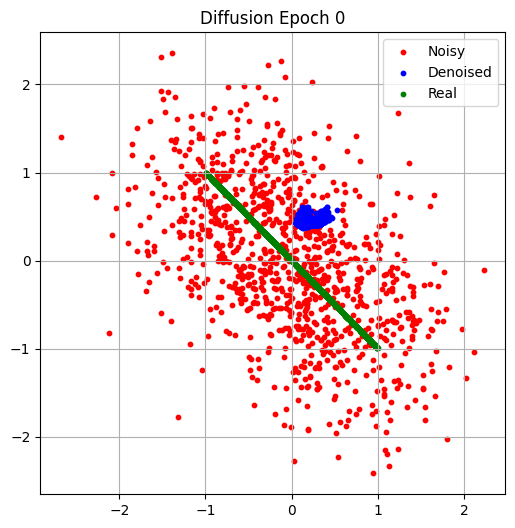

Epoch 0 Loss = 0.5103


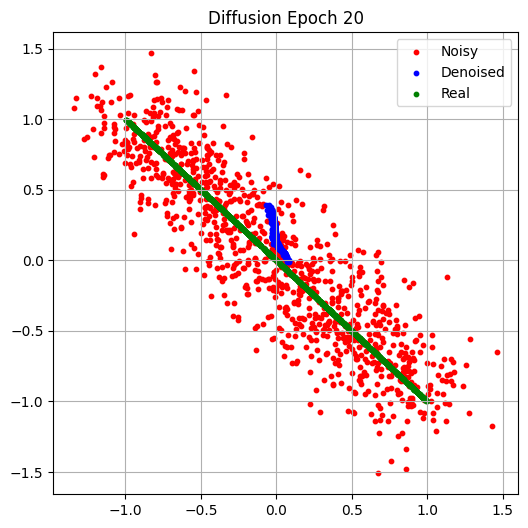

Epoch 20 Loss = 0.3013


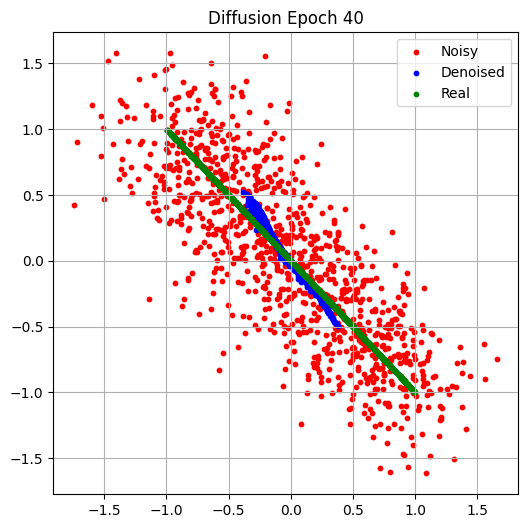

Epoch 40 Loss = 0.1659


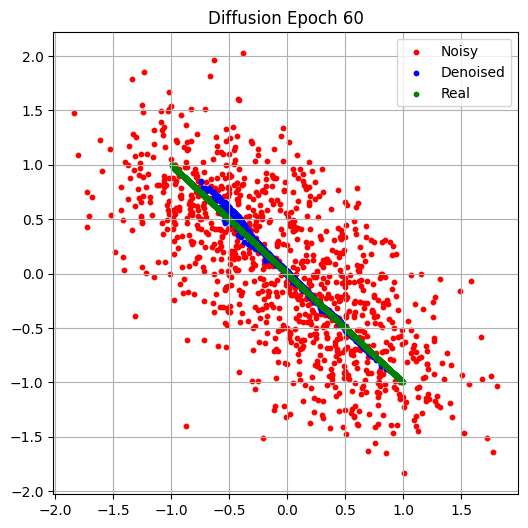

Epoch 60 Loss = 0.0908


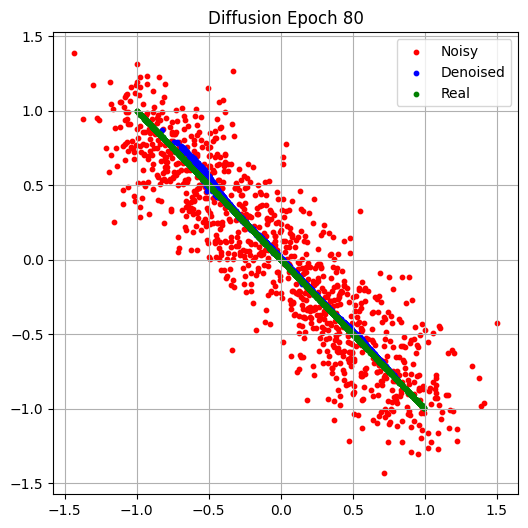

Epoch 80 Loss = 0.0400


In [31]:
# -------------------------
# Diffusion Training
# -------------------------
for epoch in range(100):

    t = torch.randint(1,T+1,(1,)).item()

    noisy_data = add_noise(real_data,t,T)

    output = denoiser(noisy_data)

    loss = criterion_mse(output,real_data)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:

        plt.figure(figsize=(6,6))

        plt.scatter(
            noisy_data[:,0].detach(),
            noisy_data[:,1].detach(),
            c='red',
            s=10,
            label='Noisy'
        )

        plt.scatter(
            output[:,0].detach(),
            output[:,1].detach(),
            c='blue',
            s=10,
            label='Denoised'
        )

        plt.scatter(
            real_data[:,0].detach(),
            real_data[:,1].detach(),
            c='green',
            s=10,
            label='Real'
        )

        plt.title(
            f'Diffusion Epoch {epoch}'
        )

        plt.legend()
        plt.grid()
        plt.show()

        print(
            f"Epoch {epoch} "
            f"Loss = {loss.item():.4f}"
        )

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

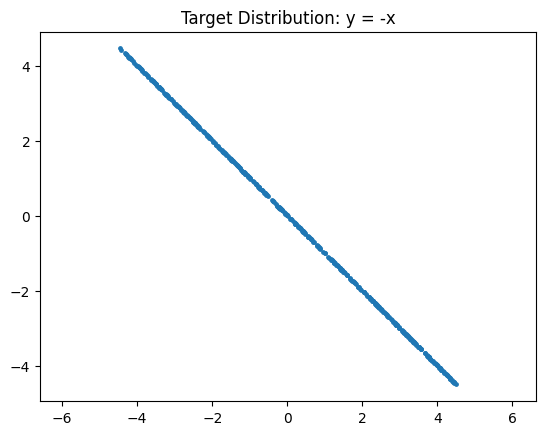

In [33]:
def sample_line_data(n_samples=512):
    x = torch.empty(n_samples, 1).uniform_(-4.5, 4.5)
    y = -x
    return torch.cat([x, y], dim=1)

plt.scatter(*sample_line_data(500).T, s=6)
plt.title("Target Distribution: y = -x")
plt.axis("equal")
plt.show()


In [34]:
steps = 120

betas = torch.linspace(2e-4, 0.015, steps)

alphas = 1.0 - betas

alpha_cum = torch.cumprod(alphas, dim=0)

In [35]:
def diffuse(x0, t):
    noise = torch.randn_like(x0)

    alpha_bar = alpha_cum[t].unsqueeze(1)

    xt = (torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * noise)

    return xt, noise

In [36]:
class NoiseEstimator(nn.Module):

    def __init__(self, dim=2, hidden=128):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(dim + 16, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, dim)
        )

    def time_embed(self, t):

        half = 8

        freqs = torch.exp(torch.linspace(0, 3, half))

        t = t.float().unsqueeze(1)

        emb = torch.cat(
            [
                torch.sin(t / freqs),
                torch.cos(t / freqs)
            ],
            dim=1
        )

        return emb

    def forward(self, x, t):

        t_emb = self.time_embed(t)

        return self.mlp(torch.cat([x, t_emb], dim=1))

In [37]:
model = NoiseEstimator()

opt = optim.Adam(model.parameters(),lr=2e-3)

loss_fn = nn.L1Loss()

epochs = 1800
batch = 128

for ep in range(epochs):

    x0 = sample_line_data(batch)

    t = torch.randint(0,steps,(batch,))

    xt, eps = diffuse(x0, t)

    eps_hat = model(xt, t)

    loss = loss_fn(eps_hat,eps)

    opt.zero_grad()

    loss.backward()

    opt.step()

    if ep % 300 == 0:
        print(
            f"epoch {ep} | "
            f"loss {loss.item():.5f}"
        )

epoch 0 | loss 0.81094
epoch 300 | loss 0.56060
epoch 600 | loss 0.54524
epoch 900 | loss 0.63055
epoch 1200 | loss 0.55736
epoch 1500 | loss 0.56805


In [38]:
@torch.no_grad()
def generate(n=800):

    x = torch.randn(n, 2)

    for t in reversed(range(steps)):

        t_batch = torch.full((n,),t)

        eps = model(x,t_batch)

        a = alphas[t]
        a_bar = alpha_cum[t]
        b = betas[t]

        coef1 = 1 / torch.sqrt(a)

        coef2 = ((1 - a) / torch.sqrt(1 - a_bar))

        noise = (
            torch.randn_like(x)
            if t > 0
            else 0
        )

        x = (
            coef1 *
            (x - coef2 * eps)
            +
            torch.sqrt(b) * noise
        )

    return x

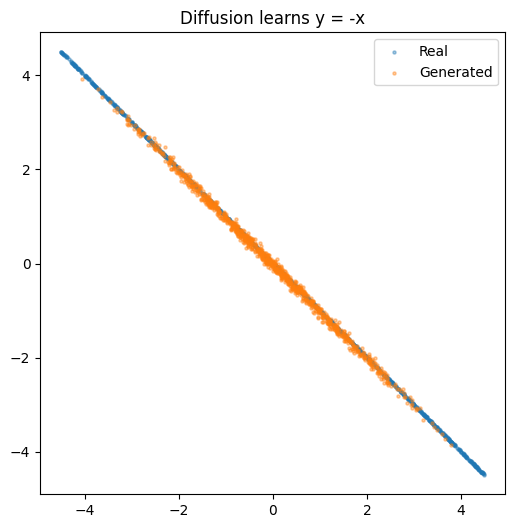

In [39]:
real = sample_line_data(1000)

fake = generate(1000)

plt.figure(figsize=(6,6))

plt.scatter(
    real[:,0],
    real[:,1],
    s=5,
    alpha=0.4,
    label="Real"
)

plt.scatter(
    fake[:,0],
    fake[:,1],
    s=5,
    alpha=0.4,
    label="Generated"
)

plt.legend()

plt.title(
    "Diffusion learns y = -x"
)

plt.axis("equal")

plt.show()